# Descriptive Data Analysis
**Correlation between Dollar Rate, Crude Oil Prices, Migration & Personal Remittances - Sri Lanka (1994-2025)**

Dataset: `SriLanka_Migration_final.csv` (384 monthly observations, 15 selected columns)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'
sns.set_theme(style='whitegrid', palette='deep')

# Load dataset
df = pd.read_csv('SriLanka_Migration_final.csv')
df['date'] = pd.to_datetime(df['date'])

# Select only the 15 required columns
cols = ['date','slbfe_total_annual','slbfe_male_annual','slbfe_female_annual',
        'slbfe_skilled_annual','slbfe_lowskilled_annual',
        'male_skilled_pct_annual','male_lowskilled_pct_annual',
        'female_skilled_pct_annual','female_lowskilled_pct_annual',
        'avg_age_annual','avg_contract_years_annual',
        'remittances_annual_usd_mn','dollar_rate_monthly','brent_oil_monthly']
df = df[cols]
df['year'] = df['date'].dt.year

# Create annual dataset by aggregating
annual = df.groupby('year').first().reset_index()
annual['dollar_rate_annual_avg'] = df.groupby('year')['dollar_rate_monthly'].mean().values
annual['brent_oil_annual_avg'] = df.groupby('year')['brent_oil_monthly'].mean().values

# Rename for convenience
annual.rename(columns={
    'slbfe_total_annual': 'emigration',
    'remittances_annual_usd_mn': 'remittances',
    'slbfe_male_annual': 'male',
    'slbfe_female_annual': 'female',
    'slbfe_skilled_annual': 'skilled',
    'slbfe_lowskilled_annual': 'lowskilled'
}, inplace=True)

print(f'Monthly dataset: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Annual dataset:  {annual.shape[0]} rows x {annual.shape[1]} columns')
print(f'Date range: {df["date"].min().strftime("%b %Y")} to {df["date"].max().strftime("%b %Y")}')
print(f'\nMissing values: {df.isnull().sum().sum()}')
print(f'Duplicate rows:  {df.duplicated().sum()}')

Monthly dataset: 384 rows x 16 columns
Annual dataset:  32 rows x 18 columns
Date range: Jan 1994 to Dec 2025

Missing values: 0
Duplicate rows:  0


## 1. Dataset Overview

In [2]:
print('=== Monthly Dataset Info ===')
print(df.dtypes)
print(f'\nShape: {df.shape}')
print(f'\n=== First 5 rows ===')
df.head()

=== Monthly Dataset Info ===
date                            datetime64[ns]
slbfe_total_annual                       int64
slbfe_male_annual                        int64
slbfe_female_annual                      int64
slbfe_skilled_annual                     int64
slbfe_lowskilled_annual                  int64
male_skilled_pct_annual                float64
male_lowskilled_pct_annual             float64
female_skilled_pct_annual              float64
female_lowskilled_pct_annual           float64
avg_age_annual                         float64
avg_contract_years_annual              float64
remittances_annual_usd_mn              float64
dollar_rate_monthly                    float64
brent_oil_monthly                      float64
year                                     int32
dtype: object

Shape: (384, 16)

=== First 5 rows ===


,date,slbfe_total_annual,slbfe_male_annual,slbfe_female_annual,slbfe_skilled_annual,slbfe_lowskilled_annual,male_skilled_pct_annual,male_lowskilled_pct_annual,female_skilled_pct_annual,female_lowskilled_pct_annual,avg_age_annual,avg_contract_years_annual,remittances_annual_usd_mn,dollar_rate_monthly,brent_oil_monthly,year
0,1994-01-01,60168,16377,43791,51344,8824,50.2,49.8,89.5,10.5,27.2,1.8,715.192444,49.4595,14.29,1994
1,1994-02-01,60168,16377,43791,51344,8824,50.2,49.8,89.5,10.5,27.2,1.8,715.192444,49.1129,13.80,1994
2,1994-03-01,60168,16377,43791,51344,8824,50.2,49.8,89.5,10.5,27.2,1.8,715.192444,48.9308,13.82,1994
3,1994-04-01,60168,16377,43791,51344,8824,50.2,49.8,89.5,10.5,27.2,1.8,715.192444,48.9251,15.23,1994
4,1994-05-01,60168,16377,43791,51344,8824,50.2,49.8,89.5,10.5,27.2,1.8,715.192444,49.0667,16.19,1994


In [3]:
print('=== Annual Dataset (first 10 years) ===')
print(f'Shape: {annual.shape}')
print(f'Years: {annual["year"].min()} to {annual["year"].max()}')
annual[['year','emigration','male','female','skilled','lowskilled',
        'remittances','dollar_rate_annual_avg','brent_oil_annual_avg']].head(10)

=== Annual Dataset (first 10 years) ===
Shape: (32, 18)
Years: 1994 to 2025


,year,emigration,male,female,skilled,lowskilled,remittances,dollar_rate_annual_avg,brent_oil_annual_avg
0,1994,60168,16377,43791,51344,8824,715.192444,49.170400,15.840833
1,1995,172489,46021,126468,148992,23497,800.969018,51.062267,17.044167
2,1996,162576,43112,119464,140647,21929,843.173016,55.297925,20.635000
3,1997,150283,37552,112731,129718,20565,933.731256,59.018467,19.118333
4,1998,159816,53867,105949,125512,34304,1013.337090,64.991000,12.779167
5,1999,179735,63720,116015,135964,43771,1064.301778,70.847950,17.846667
6,2000,182188,59793,122395,146429,35759,1154.285559,76.982783,28.522500
7,2001,184007,59807,124200,150622,33385,1169.810000,89.617125,24.450000
8,2002,203773,70522,133251,167288,36485,1296.070000,95.755683,24.963333
9,2003,209846,74508,135338,165582,44264,1423.470000,96.541792,28.882500


## 2. Descriptive Statistics — Key Variables (Annual, n=32)

In [4]:
key_annual = annual[['emigration','remittances','dollar_rate_annual_avg','brent_oil_annual_avg']]

desc = pd.DataFrame({
    'Count': key_annual.count(),
    'Mean': key_annual.mean(),
    'Median': key_annual.median(),
    'Mode': key_annual.mode().iloc[0],
    'Std Dev': key_annual.std(),
    'Variance': key_annual.var(),
    'Min': key_annual.min(),
    'Max': key_annual.max(),
    'Range': key_annual.max() - key_annual.min(),
    'Q1': key_annual.quantile(0.25),
    'Q3': key_annual.quantile(0.75),
    'IQR': key_annual.quantile(0.75) - key_annual.quantile(0.25),
    'Skewness': key_annual.skew(),
    'Kurtosis': key_annual.kurtosis(),
    'CV (%)': (key_annual.std() / key_annual.mean()) * 100
})
print('=== Descriptive Statistics: Key Variables (Annual, 1994-2025) ===')
desc.round(2)

=== Descriptive Statistics: Key Variables (Annual, 1994-2025) ===


,Count,Mean,Median,Mode,Std Dev,Variance,Min,Max,Range,Q1,Q3,IQR,Skewness,Kurtosis,CV (%)
emigration,32,217424.94,213350.50,53711.00,65826.35,4.333109e+09,53711.00,314786.00,261075.00,181574.75,264459.00,82884.25,-0.69,0.47,30.28
remittances,32,3943.09,3578.04,715.19,2617.80,6.852887e+06,715.19,8076.20,7361.01,1264.50,6728.39,5463.88,0.13,-1.73,66.39
dollar_rate_annual_avg,32,136.49,111.79,49.17,77.53,6.011400e+03,49.17,327.10,277.93,94.22,154.94,60.72,1.40,1.27,56.81
brent_oil_annual_avg,32,57.49,57.95,12.78,31.37,9.840500e+02,12.78,111.65,98.87,27.63,79.77,52.13,0.20,-1.14,54.57


## 3. Shapiro-Wilk Normality Test (Annual, n=32)

In [5]:
print('=== Shapiro-Wilk Normality Test (Annual Key Variables) ===')
print(f'{"Variable":30s} {"W Stat":>10s} {"p-value":>12s} {"Result":>15s}')
print('-' * 70)
for col, name in [('emigration','Emigration'), ('remittances','Remittances'),
                   ('dollar_rate_annual_avg','Dollar Rate'), ('brent_oil_annual_avg','Brent Oil')]:
    w, p = stats.shapiro(annual[col])
    result = 'Normal (p>0.05)' if p > 0.05 else 'Non-normal ***'
    print(f'{name:30s} {w:10.4f} {p:12.4f} {result:>15s}')
print()
print('Implication: Variables with non-normal distributions (Remittances, Dollar Rate)')
print('may benefit from supplementary non-parametric analysis (e.g. Spearman rank).')
print('However, Pearson r is reasonably robust to moderate non-normality for n=32.')

=== Shapiro-Wilk Normality Test (Annual Key Variables) ===
Variable                           W Stat      p-value          Result
----------------------------------------------------------------------
Emigration                         0.9480       0.1265 Normal (p>0.05)
Remittances                        0.8594       0.0007  Non-normal ***
Dollar Rate                        0.8285       0.0001  Non-normal ***
Brent Oil                          0.9356       0.0564 Normal (p>0.05)

Implication: Variables with non-normal distributions (Remittances, Dollar Rate)
may benefit from supplementary non-parametric analysis (e.g. Spearman rank).
However, Pearson r is reasonably robust to moderate non-normality for n=32.


## 4. Descriptive Statistics — Supporting Variables (Annual)

In [6]:
support_cols = ['male_skilled_pct_annual','male_lowskilled_pct_annual',
                'female_skilled_pct_annual','female_lowskilled_pct_annual',
                'avg_age_annual','avg_contract_years_annual']
support = annual[support_cols]

desc_s = pd.DataFrame({
    'Count': support.count(),
    'Mean': support.mean(),
    'Median': support.median(),
    'Std Dev': support.std(),
    'Min': support.min(),
    'Max': support.max(),
    'Range': support.max() - support.min(),
    'Skewness': support.skew(),
    'Kurtosis': support.kurtosis(),
    'CV (%)': (support.std() / support.mean()) * 100
})
print('=== Descriptive Statistics: Supporting Variables (Annual, 1994-2025) ===')
desc_s.round(2)

=== Descriptive Statistics: Supporting Variables (Annual, 1994-2025) ===


,Count,Mean,Median,Std Dev,Min,Max,Range,Skewness,Kurtosis,CV (%)
male_skilled_pct_annual,32,59.27,58.82,4.97,50.20,68.53,18.33,0.03,-0.69,8.39
male_lowskilled_pct_annual,32,40.73,41.18,4.97,31.47,49.80,18.33,-0.03,-0.69,12.20
female_skilled_pct_annual,32,90.04,91.12,5.38,71.28,97.56,26.28,-1.86,4.57,5.97
female_lowskilled_pct_annual,32,9.96,8.88,5.38,2.44,28.72,26.28,1.86,4.57,53.97
avg_age_annual,32,30.32,30.40,1.72,27.20,33.10,5.90,-0.16,-1.13,5.69
avg_contract_years_annual,32,2.42,2.35,0.46,1.80,3.50,1.70,0.70,-0.15,19.06


## 5. Full Descriptive Statistics — All Annual Variables

In [7]:
all_vars = annual[['emigration','male','female','skilled','lowskilled',
                    'male_skilled_pct_annual','male_lowskilled_pct_annual',
                    'female_skilled_pct_annual','female_lowskilled_pct_annual',
                    'avg_age_annual','avg_contract_years_annual',
                    'remittances','dollar_rate_annual_avg','brent_oil_annual_avg']]

full_desc = pd.DataFrame({
    'Count': all_vars.count(),
    'Mean': all_vars.mean(),
    'Median': all_vars.median(),
    'Std Dev': all_vars.std(),
    'Min': all_vars.min(),
    'Max': all_vars.max()
})
print('=== Full Descriptive Statistics Table (Annual, n=32) ===')
full_desc.round(2)

=== Full Descriptive Statistics Table (Annual, n=32) ===


,Count,Mean,Median,Std Dev,Min,Max
emigration,32,217424.94,213350.50,65826.35,53711.00,314786.00
male,32,108564.69,111428.50,52208.51,16377.00,190217.00
female,32,108860.25,118748.50,29828.66,21211.00,138312.00
skilled,32,165568.19,166408.00,47328.01,37600.00,244467.00
lowskilled,32,58224.09,58374.00,28884.43,8824.00,132283.00
male_skilled_pct_annual,32,59.27,58.82,4.97,50.20,68.53
male_lowskilled_pct_annual,32,40.73,41.18,4.97,31.47,49.80
female_skilled_pct_annual,32,90.04,91.12,5.38,71.28,97.56
female_lowskilled_pct_annual,32,9.96,8.88,5.38,2.44,28.72
avg_age_annual,32,30.32,30.40,1.72,27.20,33.10


## 6. Descriptive Statistics — Monthly Variables (n=384)

In [8]:
monthly_vars = df[['dollar_rate_monthly','brent_oil_monthly']]

desc_m = pd.DataFrame({
    'Count': monthly_vars.count(),
    'Mean': monthly_vars.mean(),
    'Median': monthly_vars.median(),
    'Std Dev': monthly_vars.std(),
    'Variance': monthly_vars.var(),
    'Min': monthly_vars.min(),
    'Max': monthly_vars.max(),
    'Range': monthly_vars.max() - monthly_vars.min(),
    'Q1': monthly_vars.quantile(0.25),
    'Q3': monthly_vars.quantile(0.75),
    'IQR': monthly_vars.quantile(0.75) - monthly_vars.quantile(0.25),
    'Skewness': monthly_vars.skew(),
    'Kurtosis': monthly_vars.kurtosis(),
    'CV (%)': (monthly_vars.std() / monthly_vars.mean()) * 100
})
print('=== Descriptive Statistics: Monthly Variables (384 observations) ===')
desc_m.round(2)

=== Descriptive Statistics: Monthly Variables (384 observations) ===


,Count,Mean,Median,Std Dev,Variance,Min,Max,Range,Q1,Q3,IQR,Skewness,Kurtosis,CV (%)
dollar_rate_monthly,384,136.49,112.24,77.29,5974.02,48.93,363.94,315.02,93.40,153.63,60.23,1.43,1.36,56.63
brent_oil_monthly,384,57.49,57.54,32.01,1024.92,9.82,132.72,122.90,26.99,78.84,51.85,0.31,-0.97,55.69


## 7. Histograms — Annual Key Variables

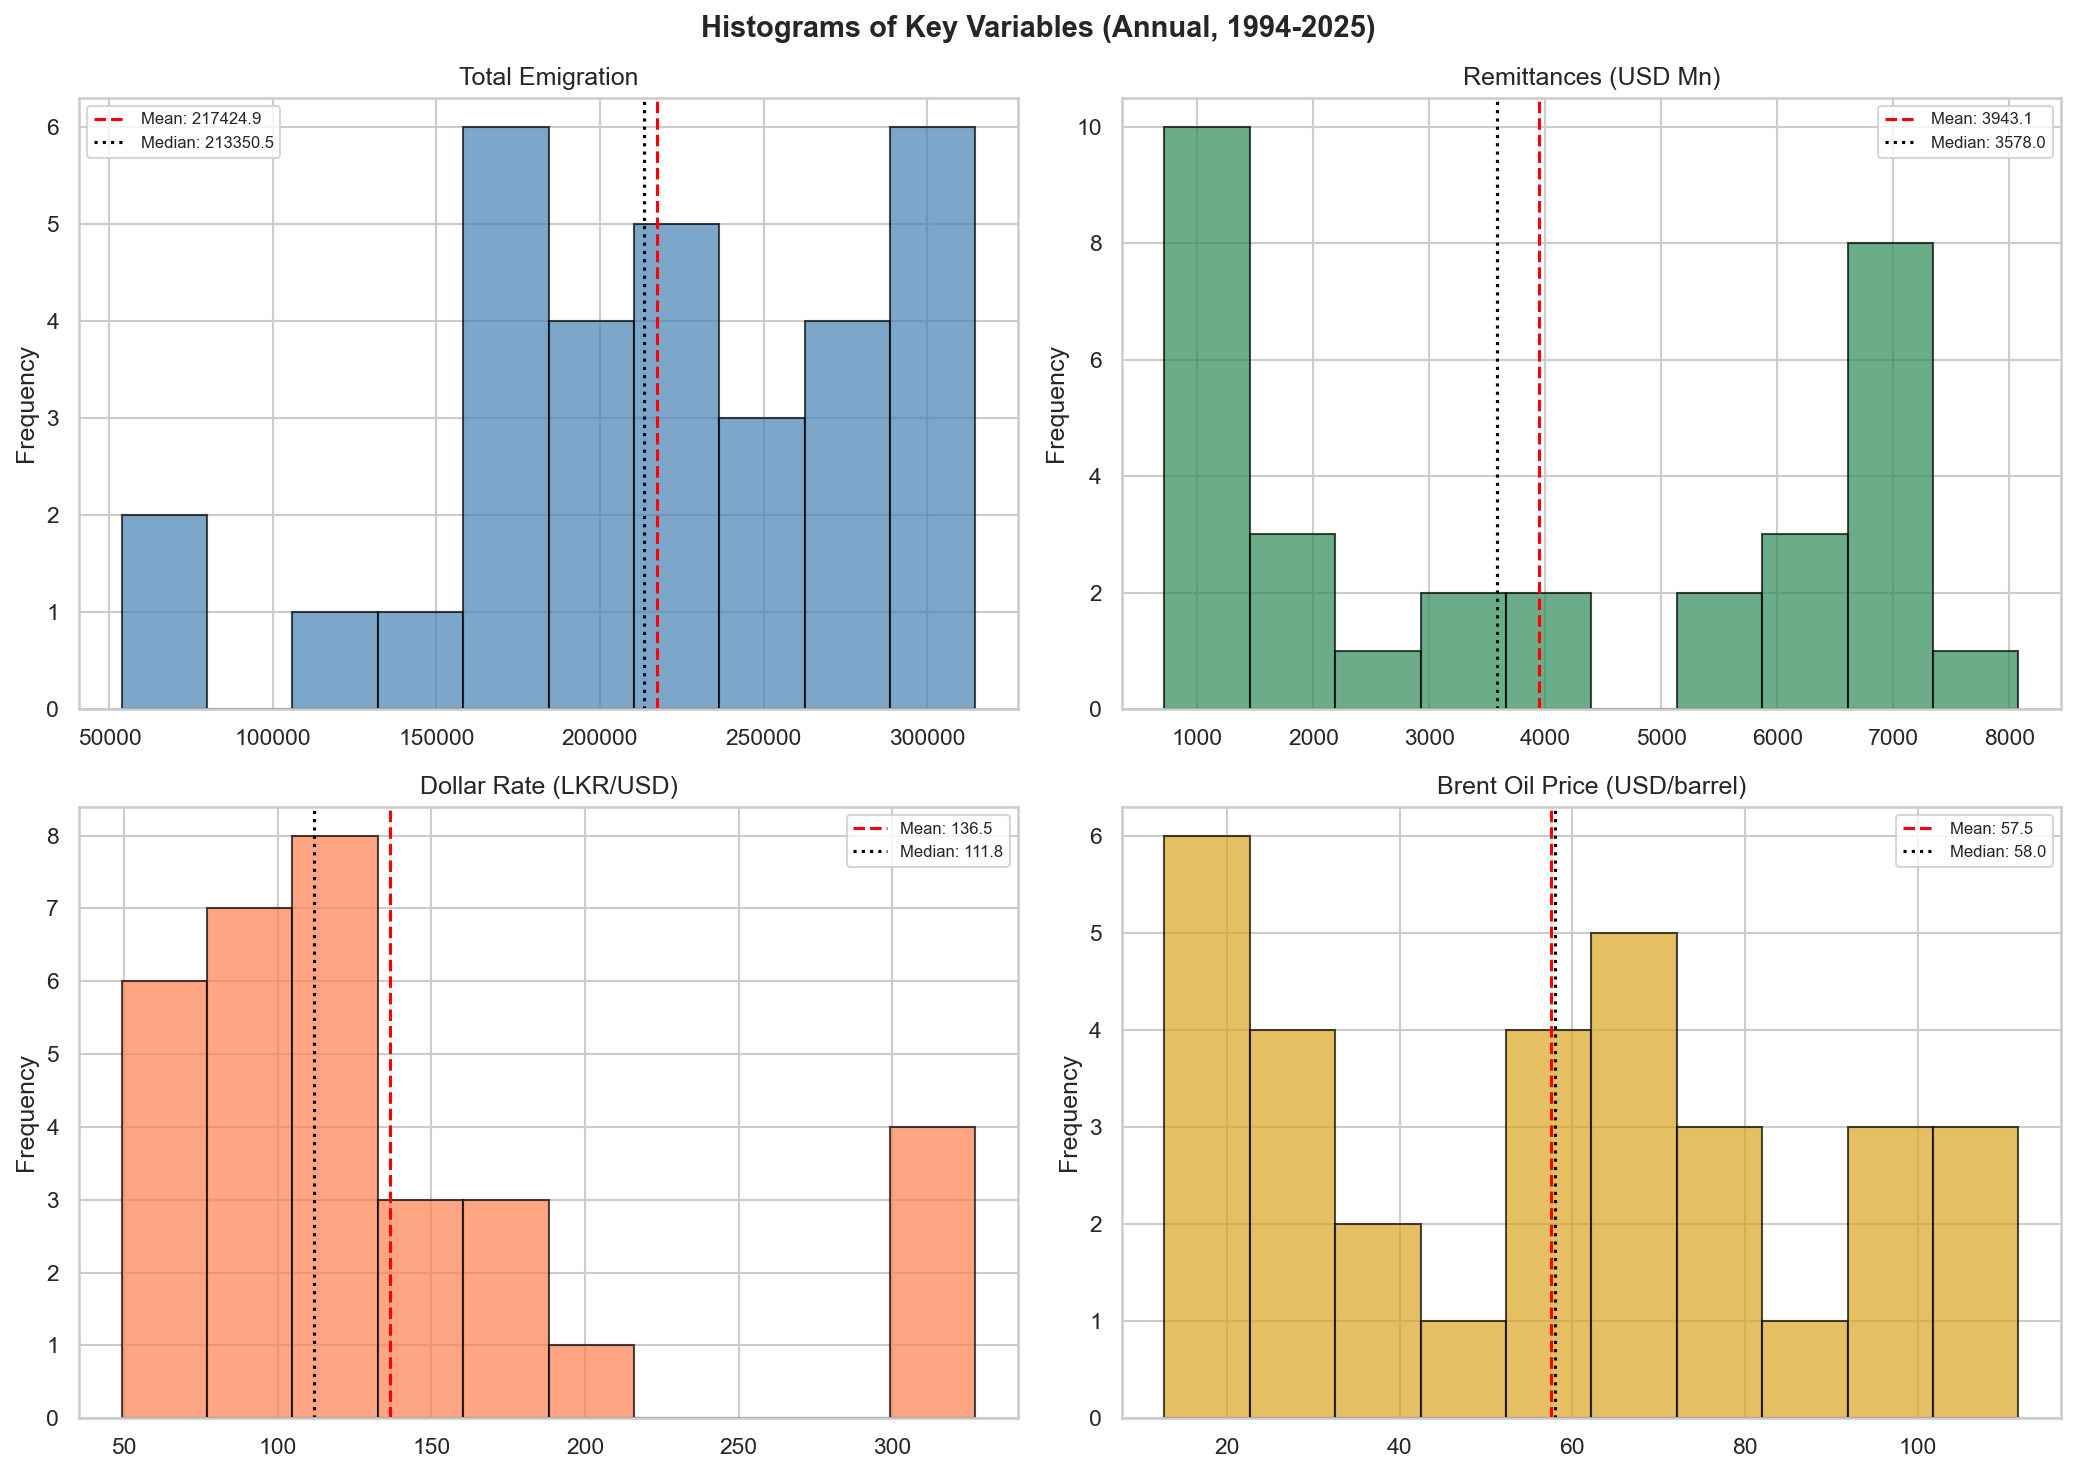

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Histograms of Key Variables (Annual, 1994-2025)', fontsize=14, fontweight='bold')

vars_info = [
    ('emigration', 'Total Emigration', 'steelblue'),
    ('remittances', 'Remittances (USD Mn)', 'seagreen'),
    ('dollar_rate_annual_avg', 'Dollar Rate (LKR/USD)', 'coral'),
    ('brent_oil_annual_avg', 'Brent Oil Price (USD/barrel)', 'goldenrod')
]

for ax, (col, title, color) in zip(axes.flat, vars_info):
    ax.hist(annual[col], bins=10, color=color, edgecolor='black', alpha=0.7)
    ax.axvline(annual[col].mean(), color='red', linestyle='--', label=f'Mean: {annual[col].mean():.1f}')
    ax.axvline(annual[col].median(), color='black', linestyle=':', label=f'Median: {annual[col].median():.1f}')
    ax.set_title(title)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('desc_histograms_annual.png')
plt.show()

## 8. Histograms — Monthly Variables

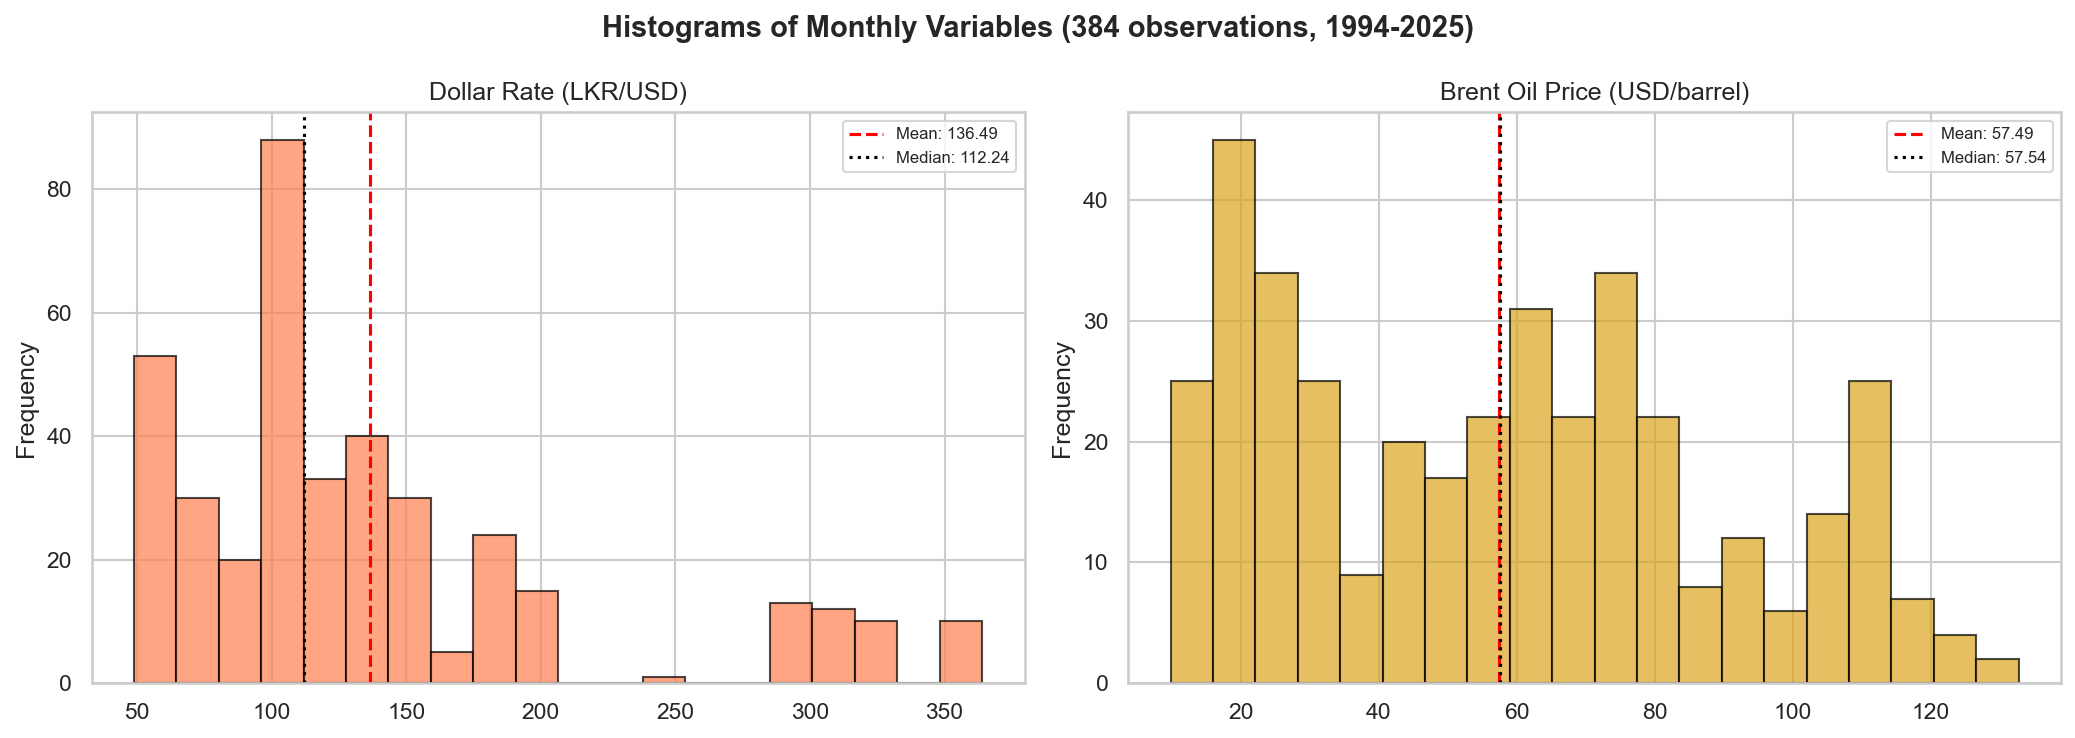

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Histograms of Monthly Variables (384 observations, 1994-2025)', fontsize=14, fontweight='bold')

for ax, (col, title, color) in zip(axes, [
    ('dollar_rate_monthly', 'Dollar Rate (LKR/USD)', 'coral'),
    ('brent_oil_monthly', 'Brent Oil Price (USD/barrel)', 'goldenrod')
]):
    ax.hist(df[col], bins=20, color=color, edgecolor='black', alpha=0.7)
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='black', linestyle=':', label=f'Median: {df[col].median():.2f}')
    ax.set_title(title)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('desc_histograms_monthly.png')
plt.show()

## 9. Box Plots — Annual Key Variables

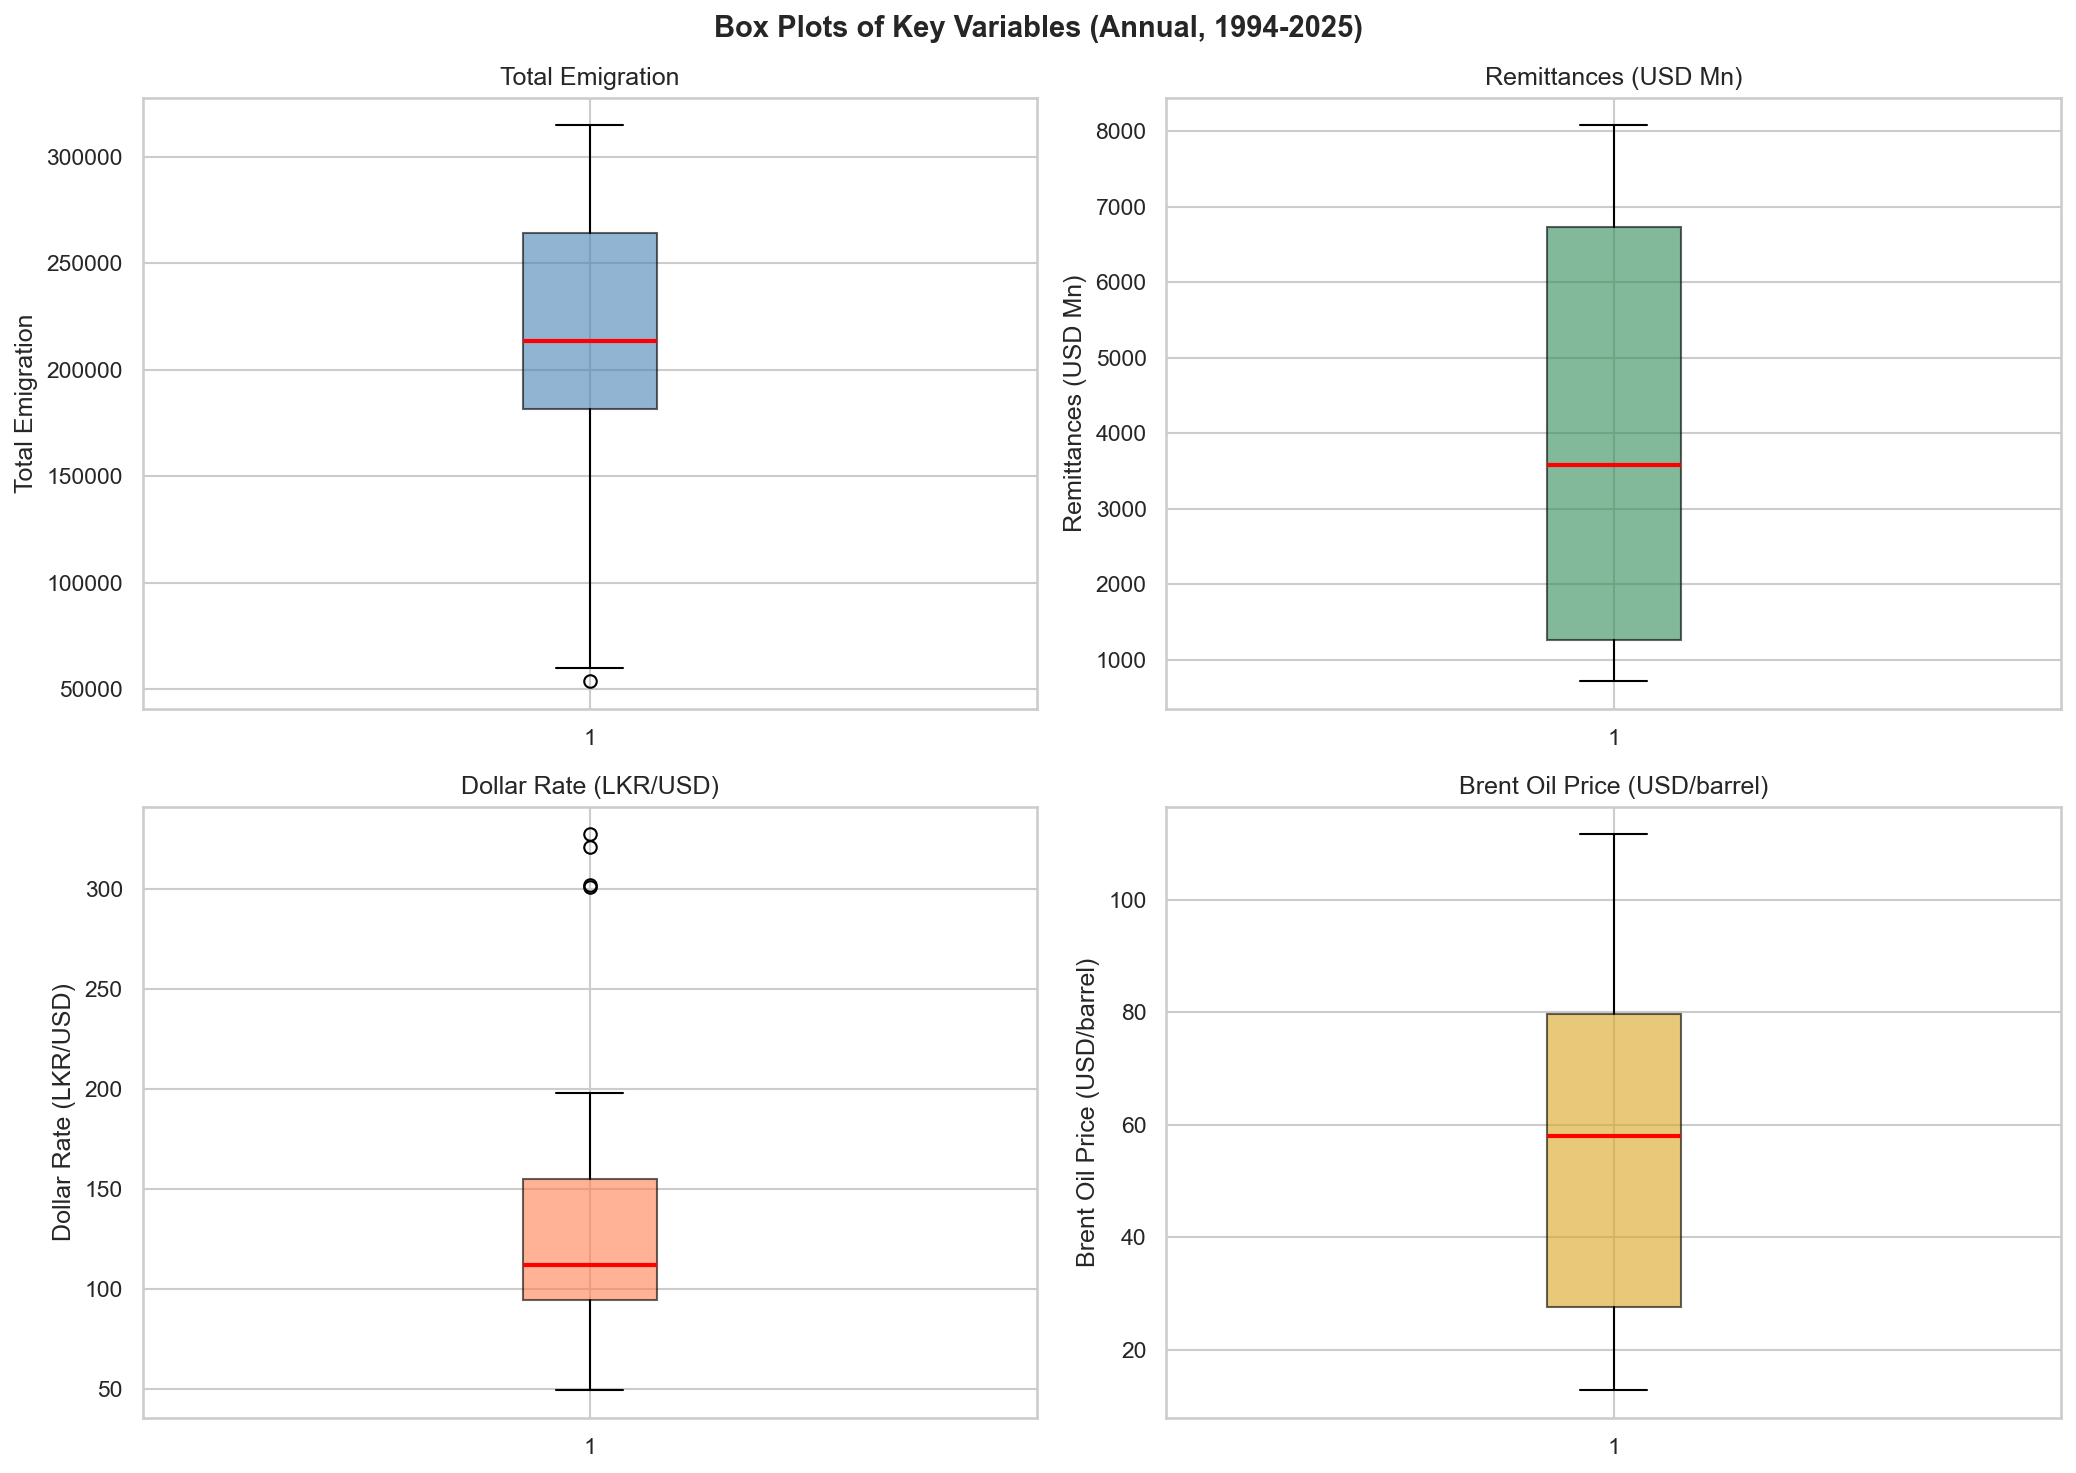

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Box Plots of Key Variables (Annual, 1994-2025)', fontsize=14, fontweight='bold')

for ax, (col, title, color) in zip(axes.flat, vars_info):
    bp = ax.boxplot(annual[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    ax.set_title(title)
    ax.set_ylabel(title)

plt.tight_layout()
plt.savefig('desc_boxplots_annual.png')
plt.show()

## 10. Box Plots — Monthly Variables

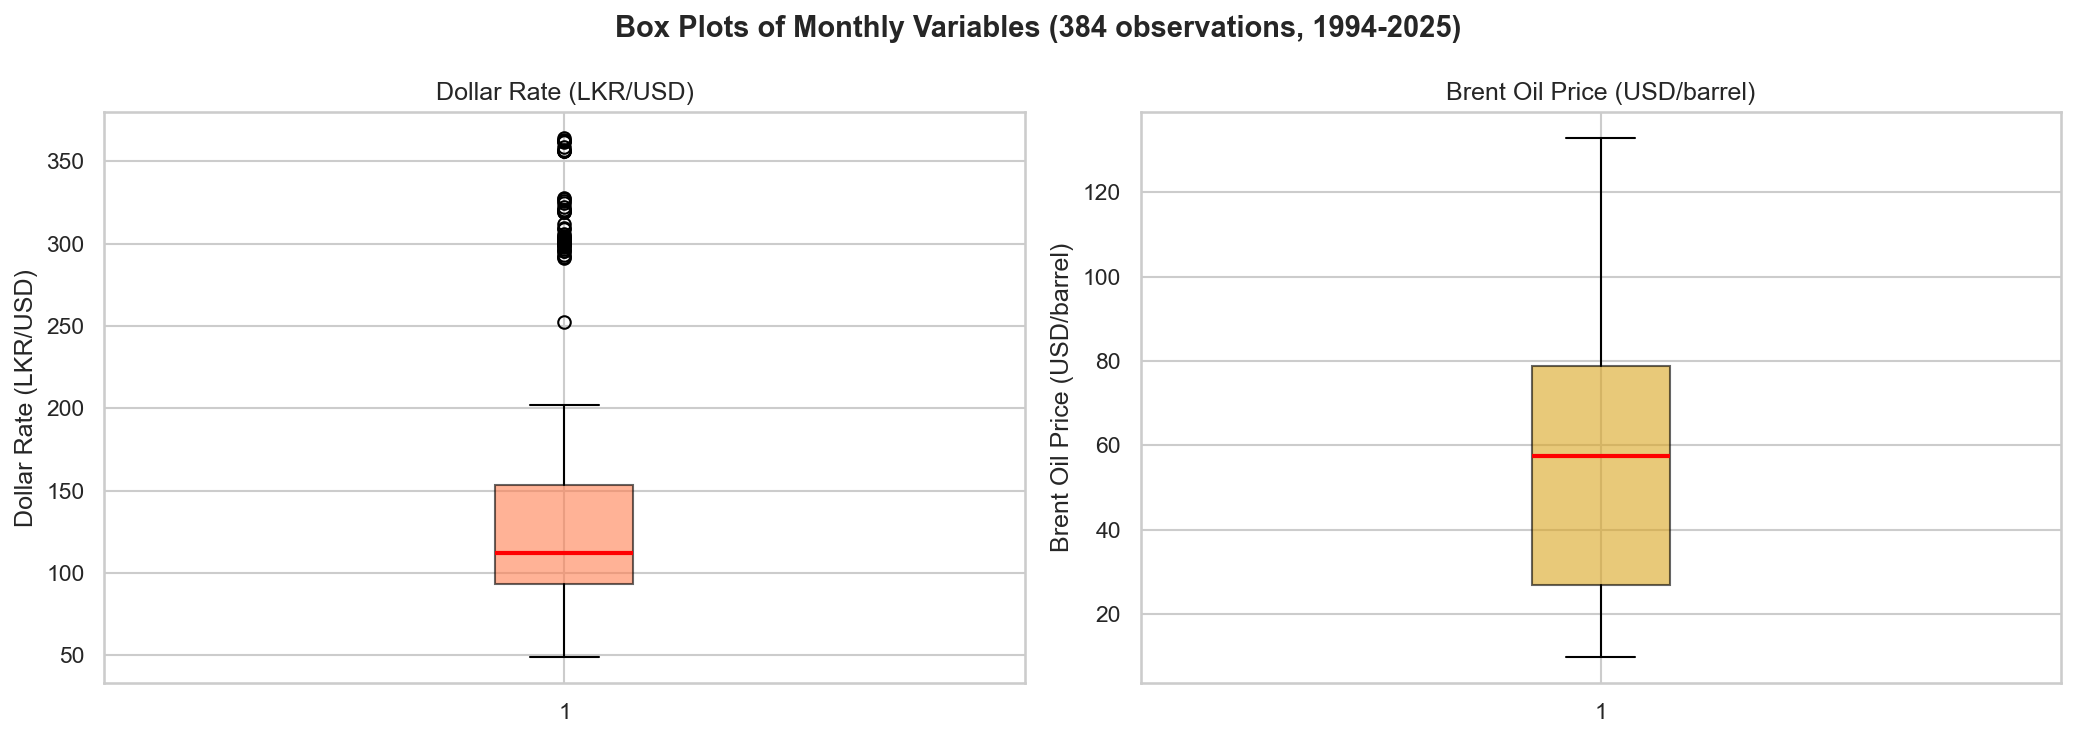

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Box Plots of Monthly Variables (384 observations, 1994-2025)', fontsize=14, fontweight='bold')

for ax, (col, title, color) in zip(axes, [
    ('dollar_rate_monthly', 'Dollar Rate (LKR/USD)', 'coral'),
    ('brent_oil_monthly', 'Brent Oil Price (USD/barrel)', 'goldenrod')
]):
    bp = ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    ax.set_title(title)
    ax.set_ylabel(title)

plt.tight_layout()
plt.savefig('desc_boxplots_monthly.png')
plt.show()

## 11. Time Series Line Plots — Annual Key Variables

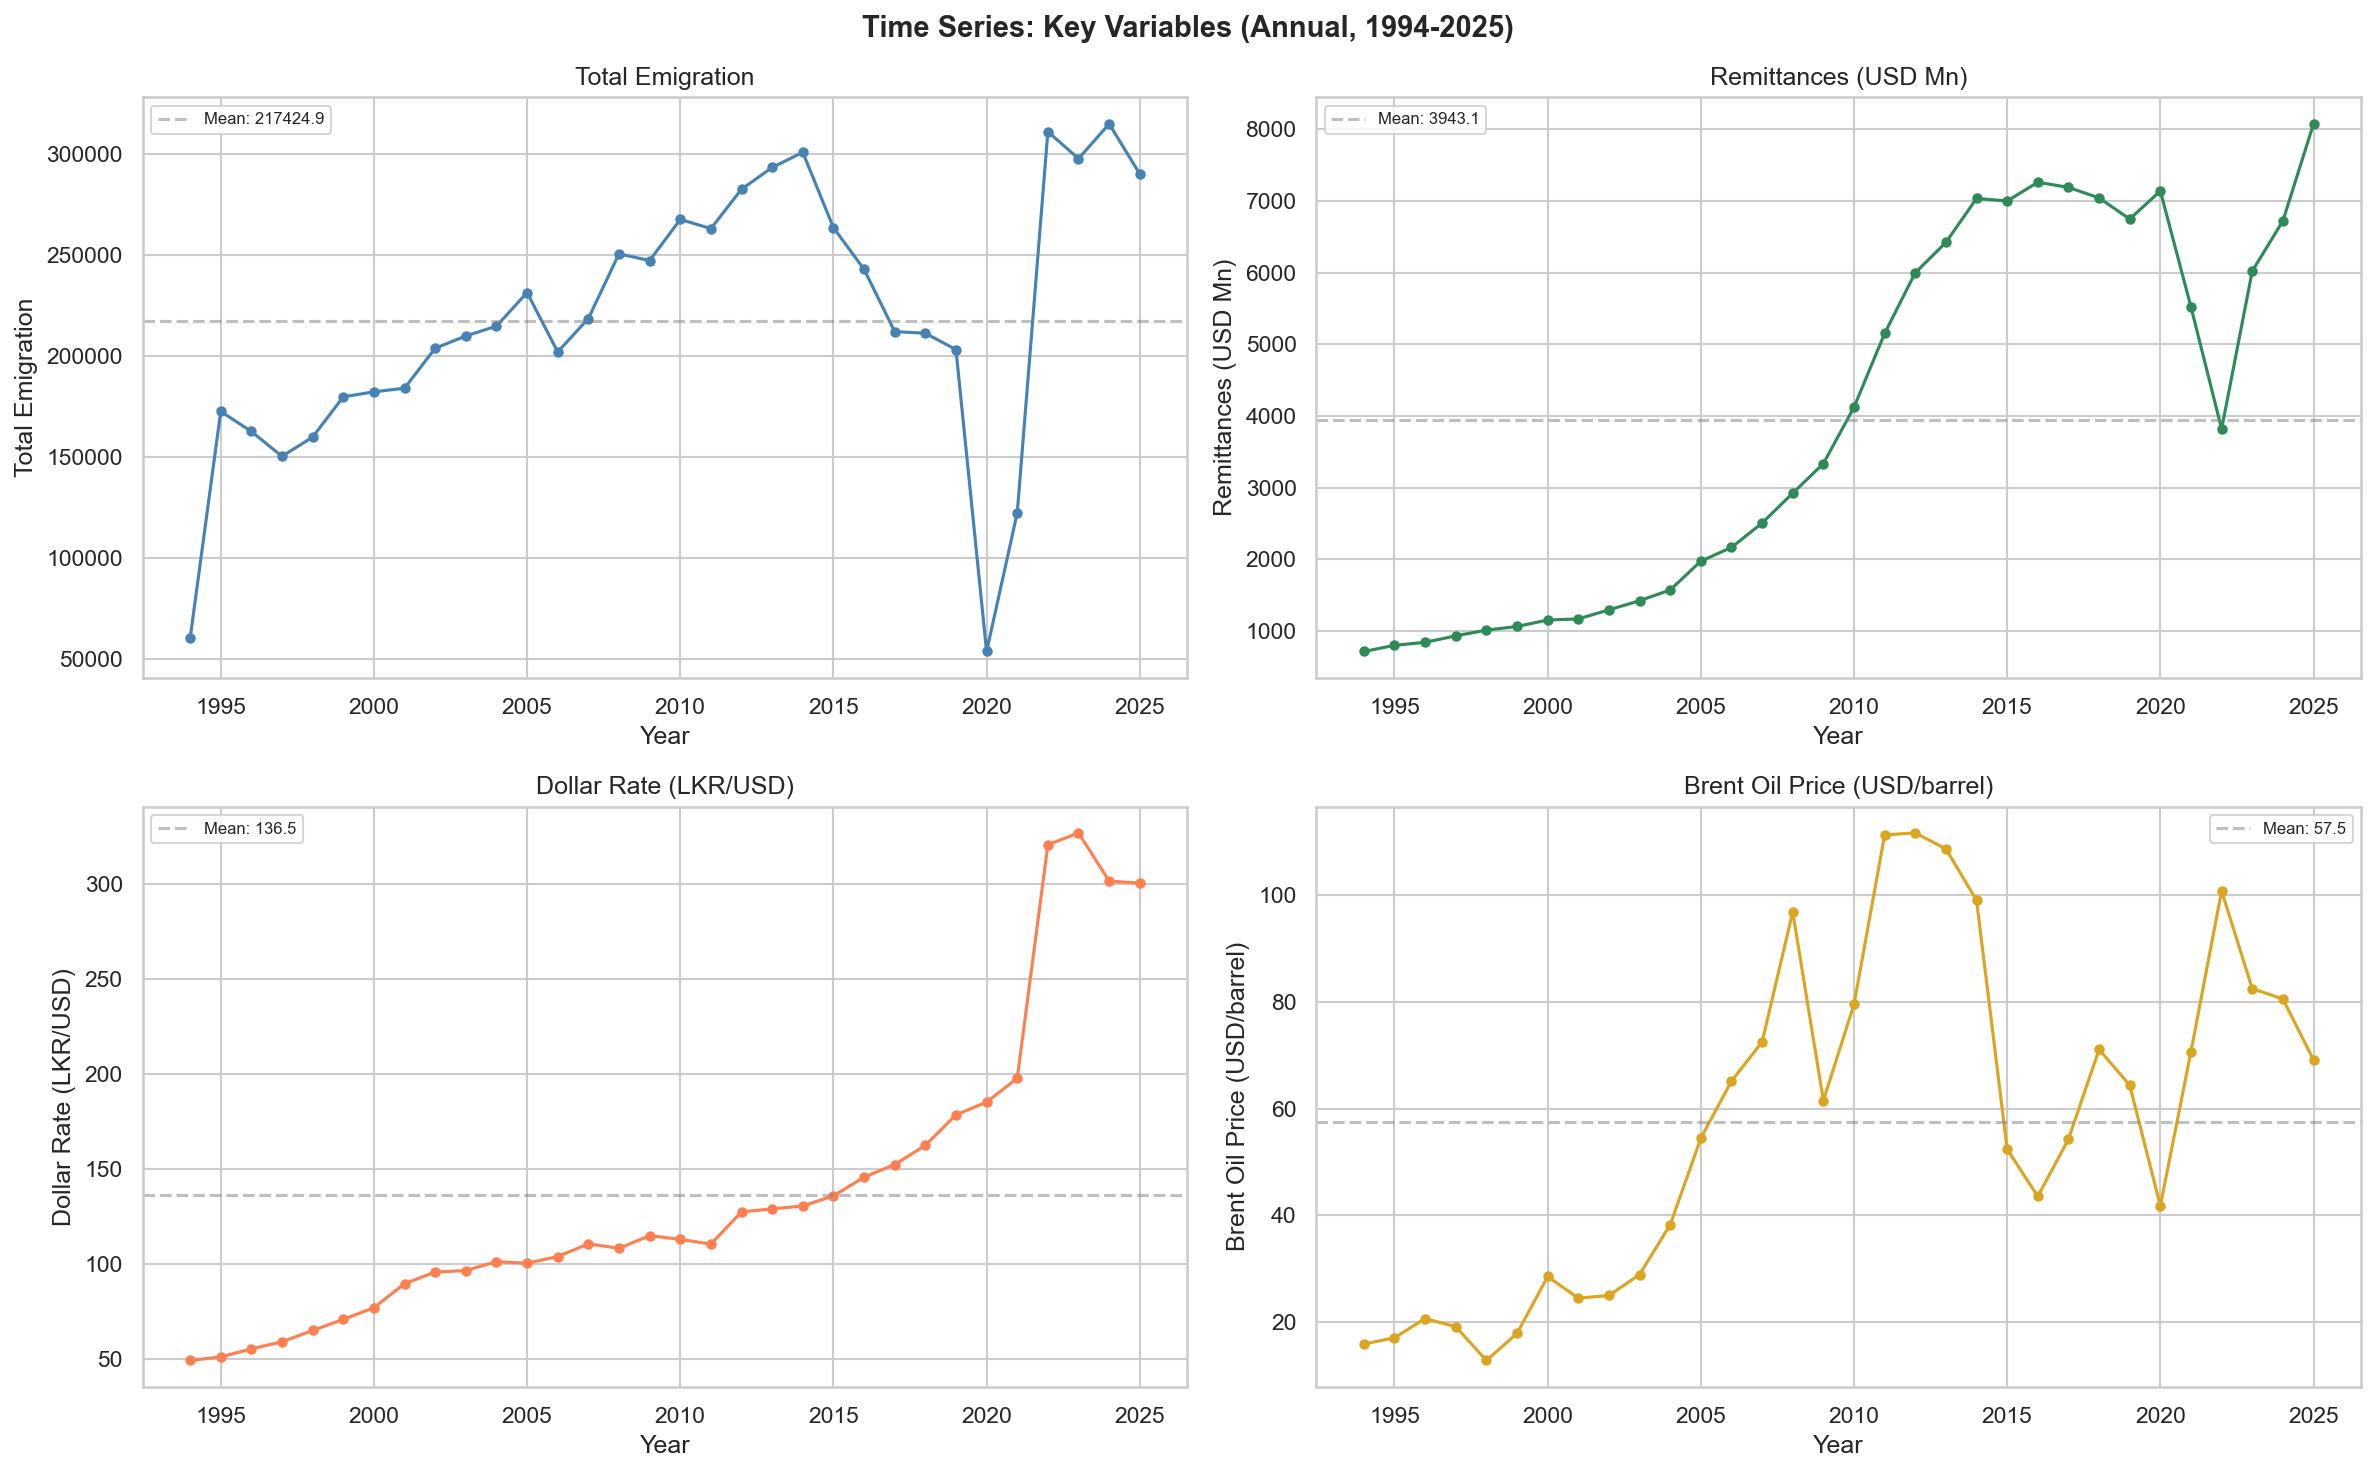

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Time Series: Key Variables (Annual, 1994-2025)', fontsize=14, fontweight='bold')

for ax, (col, title, color) in zip(axes.flat, vars_info):
    ax.plot(annual['year'], annual[col], marker='o', color=color, linewidth=1.5, markersize=4)
    ax.axhline(annual[col].mean(), color='gray', linestyle='--', alpha=0.5, label=f'Mean: {annual[col].mean():.1f}')
    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.set_ylabel(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('desc_timeseries_annual.png')
plt.show()

## 12. Time Series Line Plots — Monthly Variables

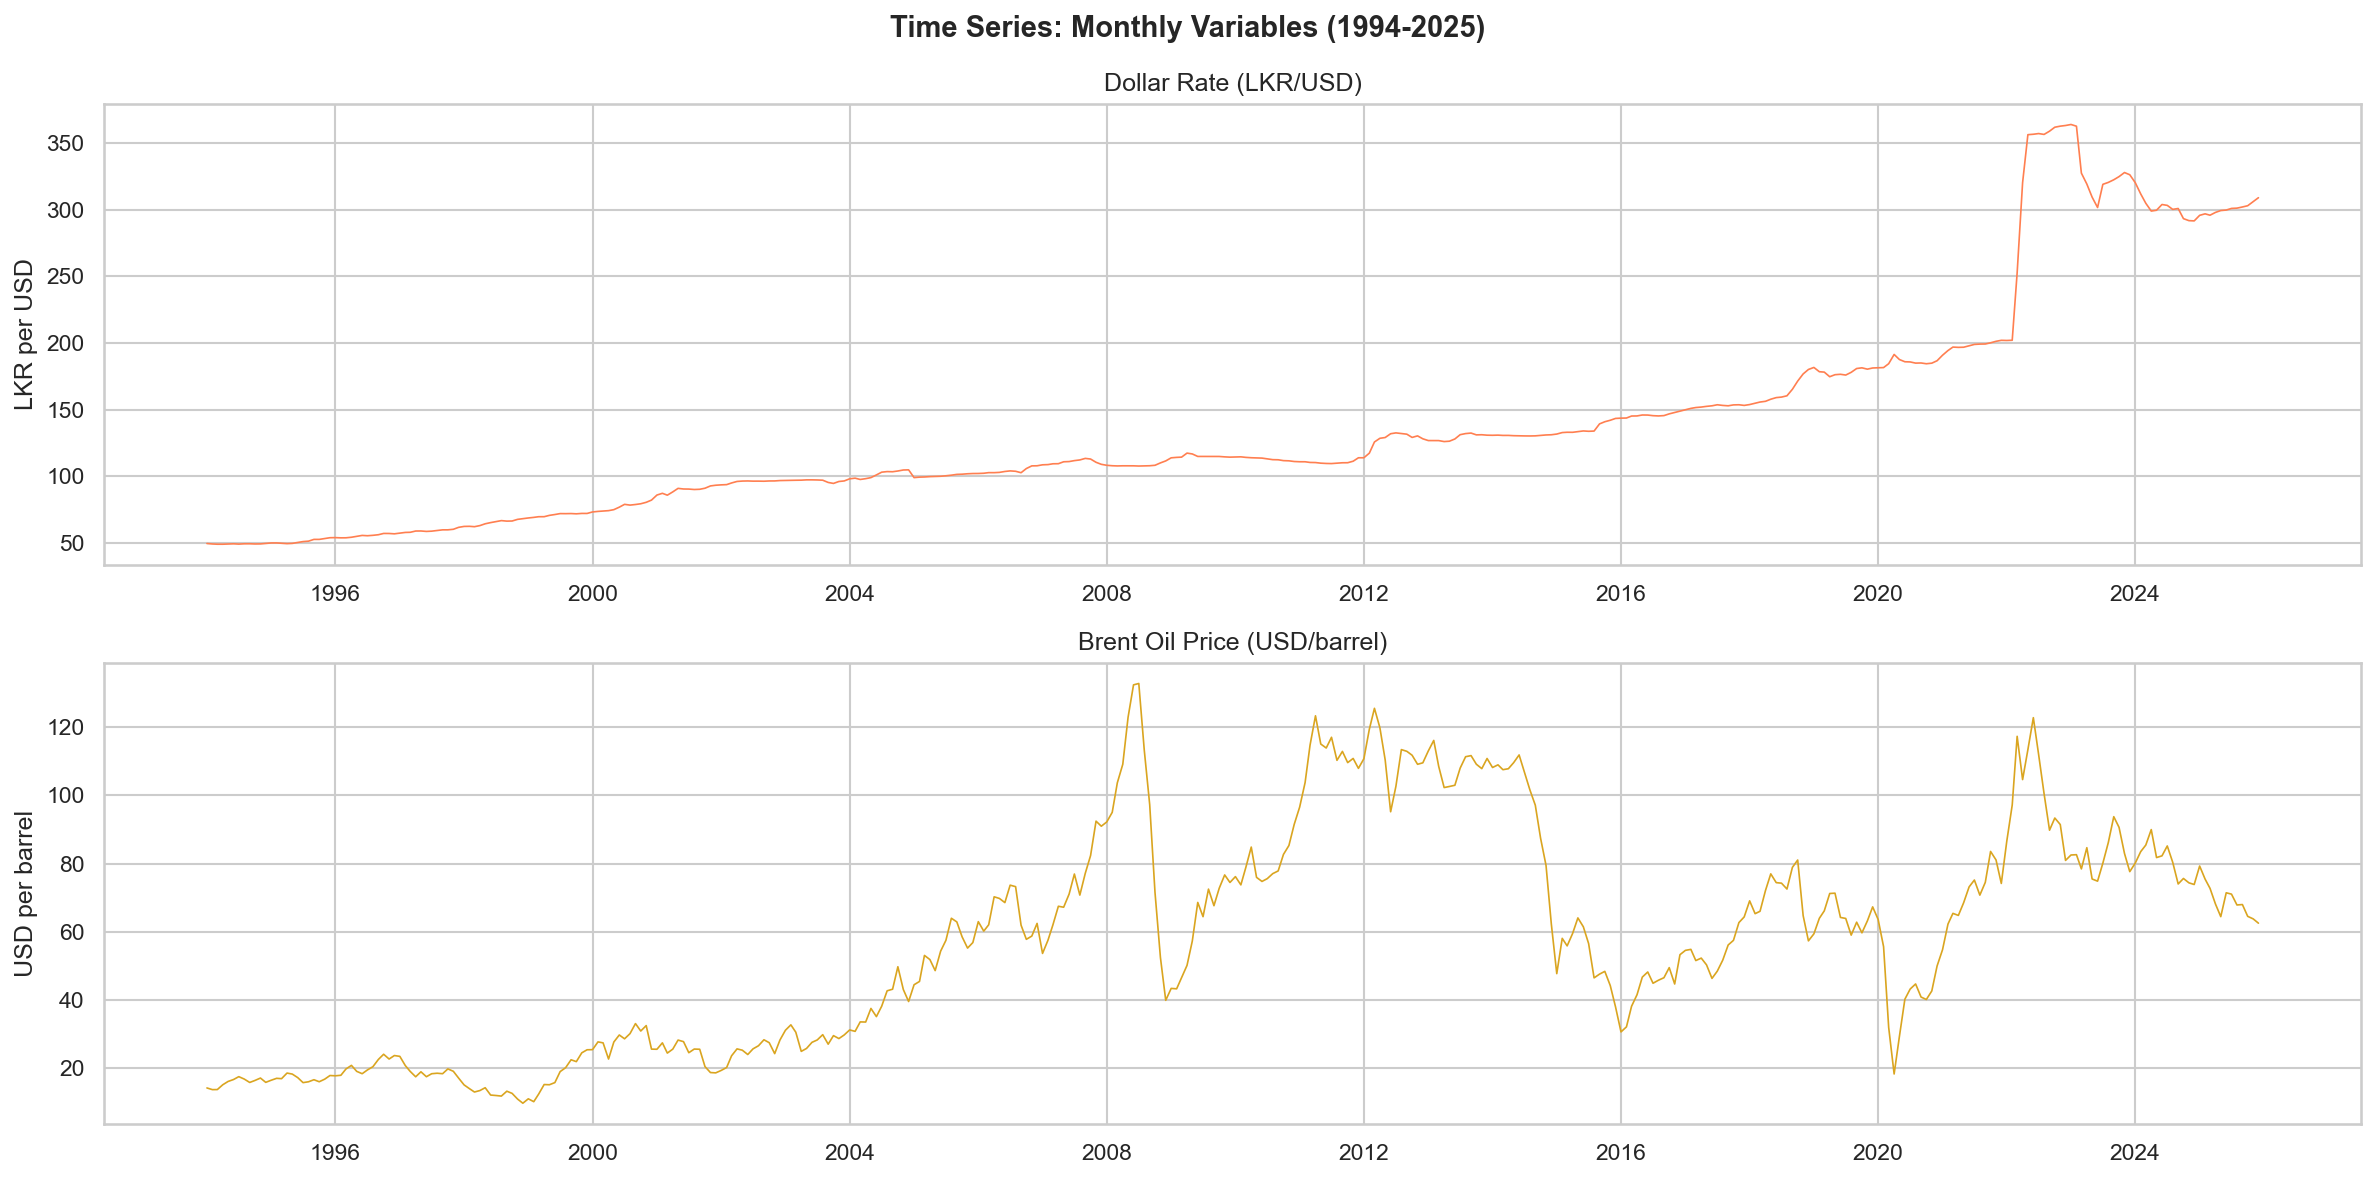

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle('Time Series: Monthly Variables (1994-2025)', fontsize=14, fontweight='bold')

axes[0].plot(df['date'], df['dollar_rate_monthly'], color='coral', linewidth=0.8)
axes[0].set_title('Dollar Rate (LKR/USD)')
axes[0].set_ylabel('LKR per USD')

axes[1].plot(df['date'], df['brent_oil_monthly'], color='goldenrod', linewidth=0.8)
axes[1].set_title('Brent Oil Price (USD/barrel)')
axes[1].set_ylabel('USD per barrel')

plt.tight_layout()
plt.savefig('desc_timeseries_monthly.png')
plt.show()

## 13. Bar Charts — Emigration & Remittances by Year

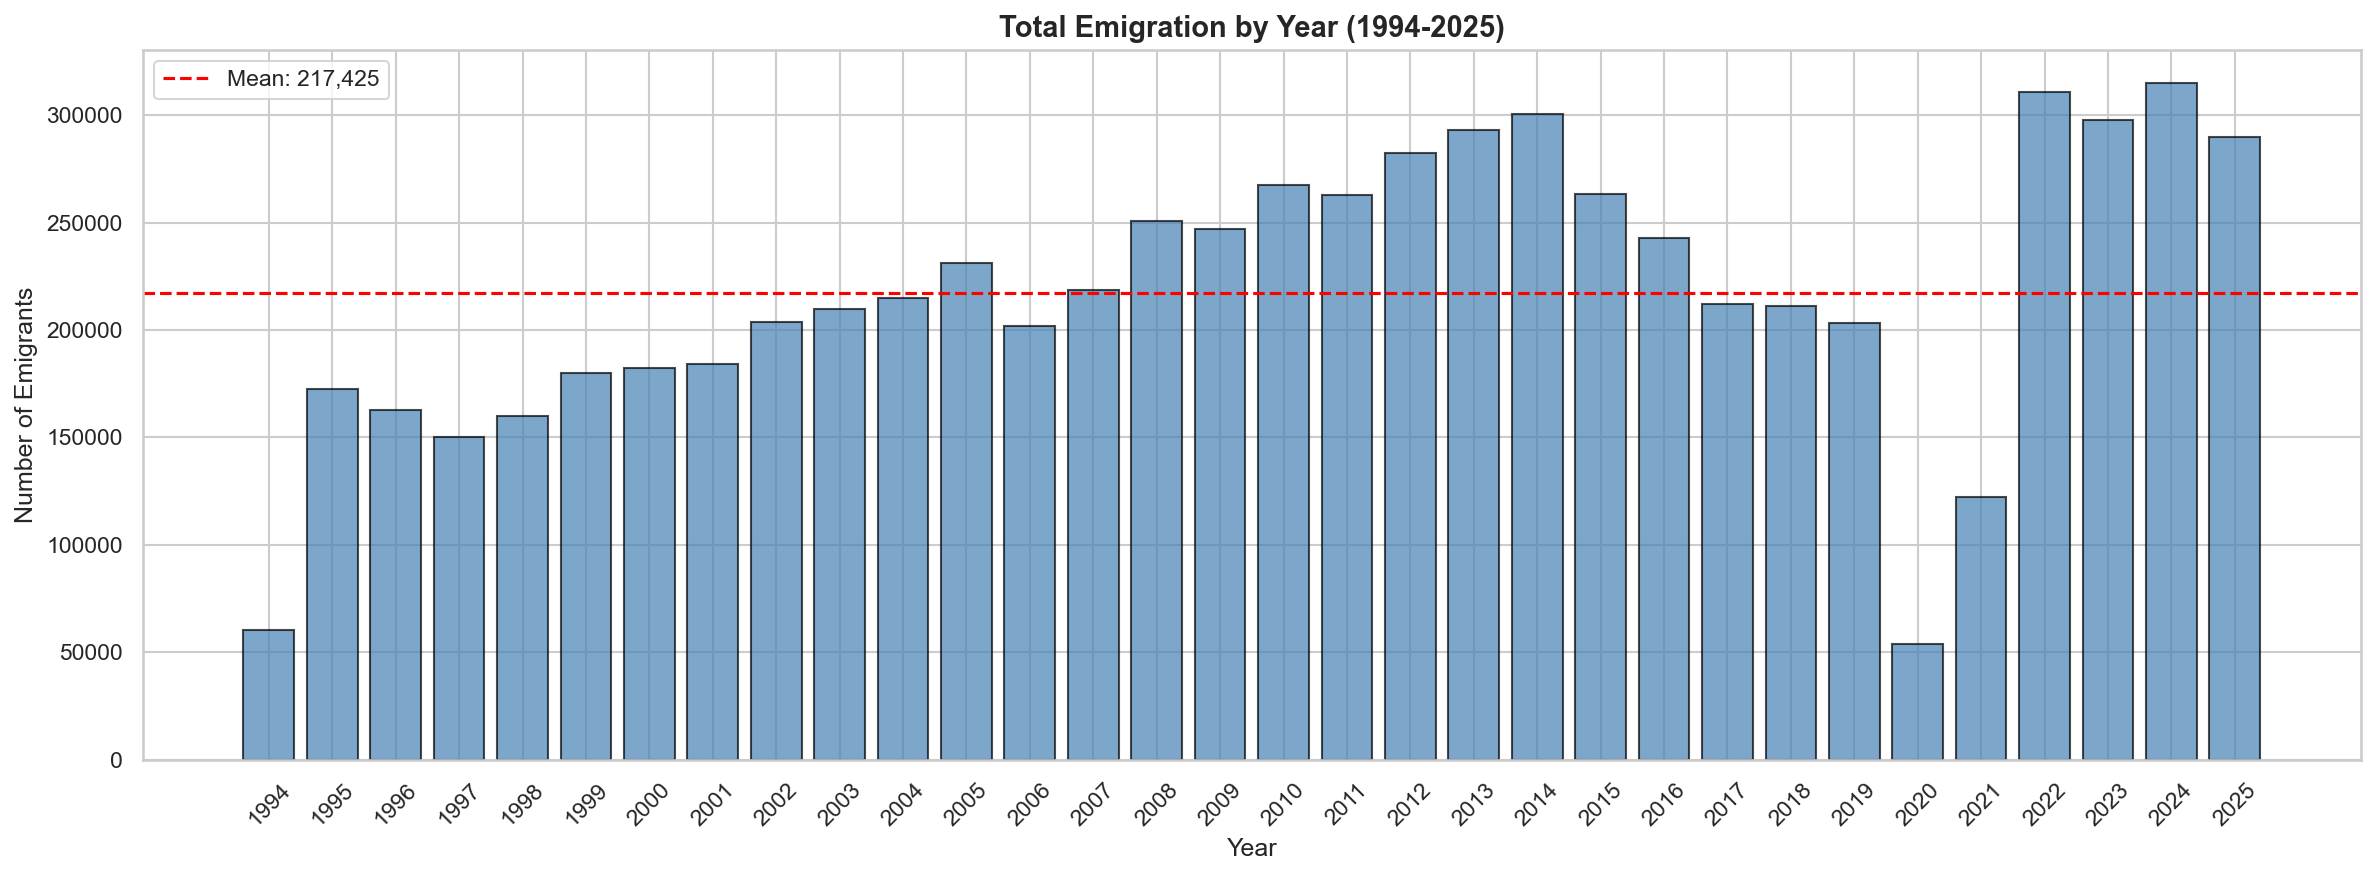

In [15]:
fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.bar(annual['year'], annual['emigration'], color='steelblue', edgecolor='black', alpha=0.7)
ax.axhline(annual['emigration'].mean(), color='red', linestyle='--', label=f'Mean: {annual["emigration"].mean():,.0f}')
ax.set_title('Total Emigration by Year (1994-2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Emigrants')
ax.legend()
plt.xticks(annual['year'], rotation=45)
plt.tight_layout()
plt.savefig('desc_bar_emigration.png')
plt.show()

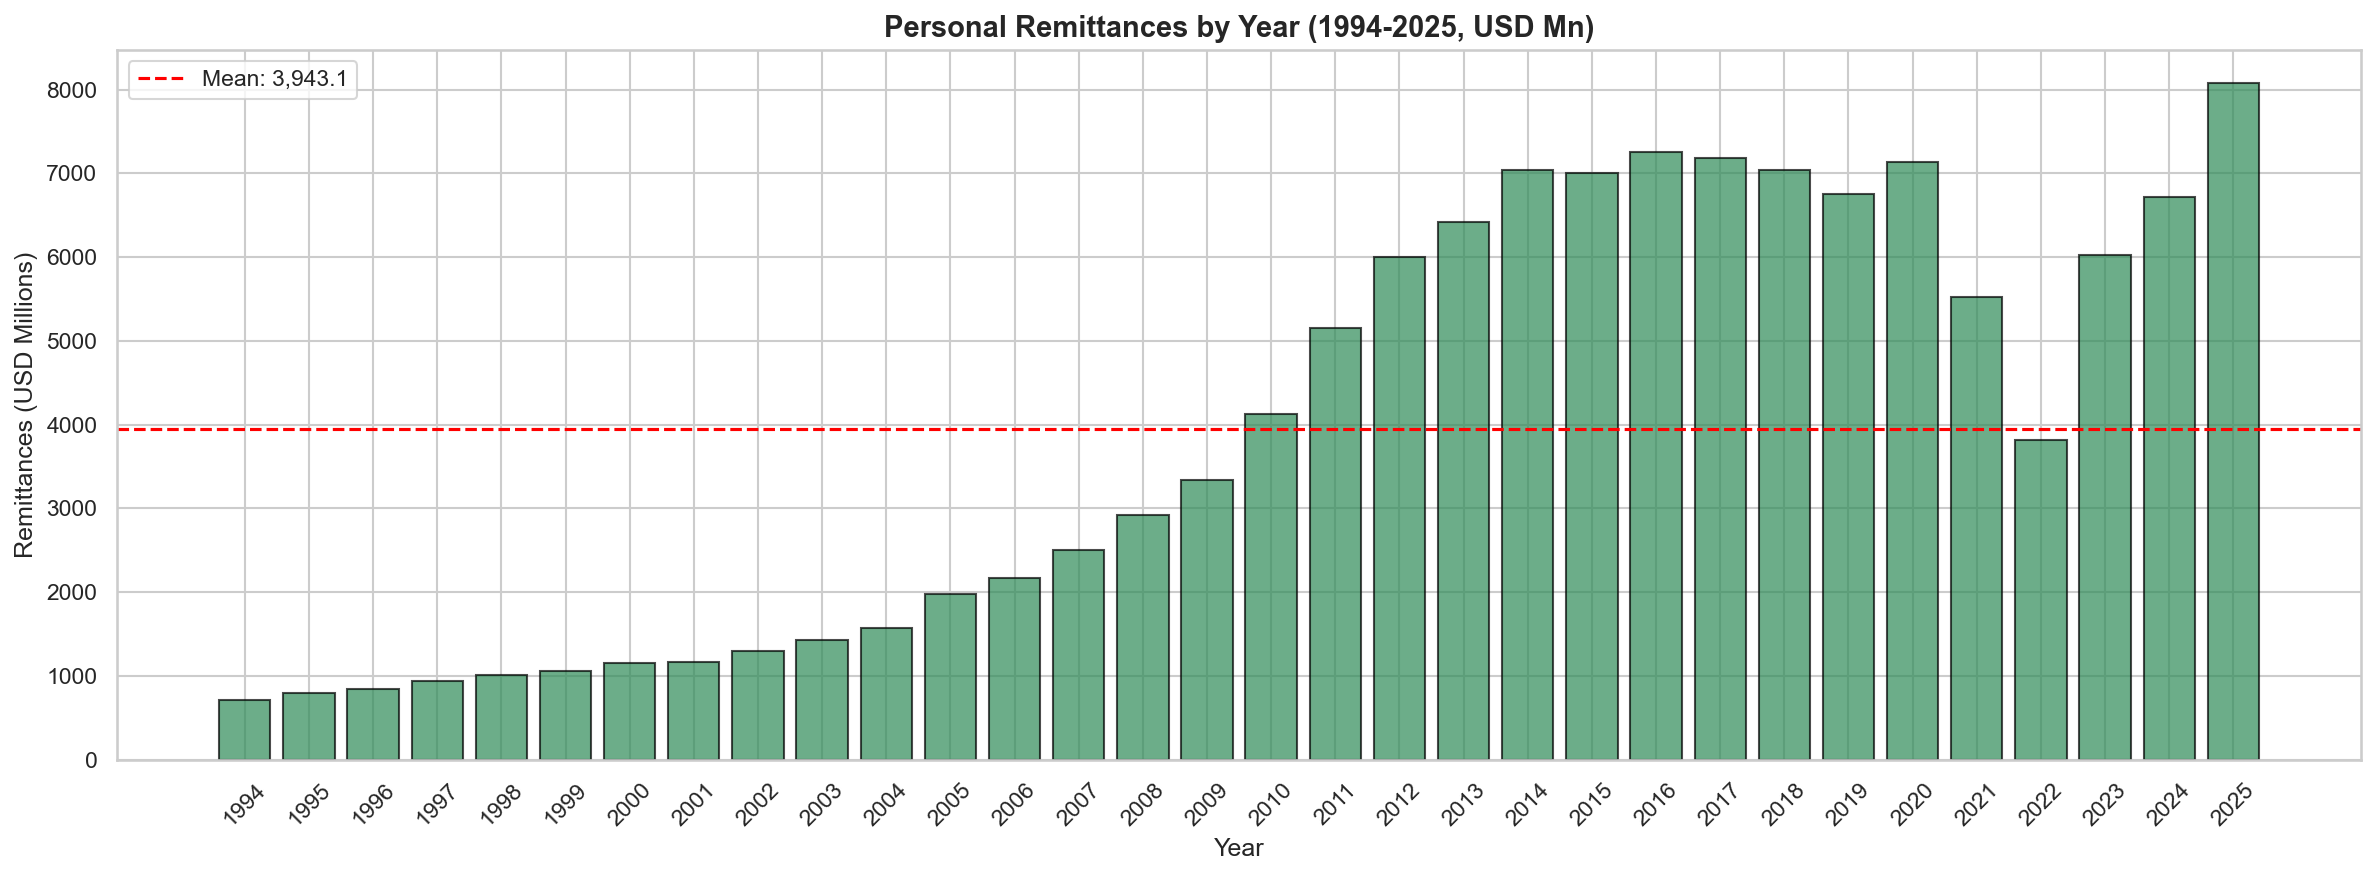

In [16]:
fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.bar(annual['year'], annual['remittances'], color='seagreen', edgecolor='black', alpha=0.7)
ax.axhline(annual['remittances'].mean(), color='red', linestyle='--', label=f'Mean: {annual["remittances"].mean():,.1f}')
ax.set_title('Personal Remittances by Year (1994-2025, USD Mn)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Remittances (USD Millions)')
ax.legend()
plt.xticks(annual['year'], rotation=45)
plt.tight_layout()
plt.savefig('desc_bar_remittances.png')
plt.show()

## 14. Year-over-Year Growth Analysis

In [17]:
yoy = pd.DataFrame()
yoy['Year'] = annual['year']
for col, name in [('emigration','Emigration'), ('remittances','Remittances'),
                   ('dollar_rate_annual_avg','Dollar Rate'), ('brent_oil_annual_avg','Brent Oil')]:
    yoy[f'{name} YoY%'] = annual[col].pct_change() * 100

print('=== Year-over-Year Growth (%) ===')
print(yoy.round(2).to_string(index=False))

print('\n=== YoY Growth Summary ===')
for col_name in ['Emigration YoY%','Remittances YoY%','Dollar Rate YoY%','Brent Oil YoY%']:
    s = yoy[col_name].dropna()
    print(f'{col_name:25s}: Mean={s.mean():+.2f}%, Max={s.max():+.2f}% ({yoy.loc[s.idxmax(),"Year"]:.0f}), Min={s.min():+.2f}% ({yoy.loc[s.idxmin(),"Year"]:.0f})')

=== Year-over-Year Growth (%) ===
 Year  Emigration YoY%  Remittances YoY%  Dollar Rate YoY%  Brent Oil YoY%
 1994              NaN               NaN               NaN             NaN
 1995           186.68             11.99              3.85            7.60
 1996            -5.75              5.27              8.30           21.07
 1997            -7.56             10.74              6.73           -7.35
 1998             6.34              8.53             10.12          -33.16
 1999            12.46              5.03              9.01           39.65
 2000             1.36              8.45              8.66           59.82
 2001             1.00              1.34             16.41          -14.28
 2002            10.74             10.79              6.85            2.10
 2003             2.98              9.83              0.82           15.70
 2004             2.32             10.56              4.88           32.36
 2005             7.72             25.53             -0.86        

## 15. Gender Composition of Emigrants

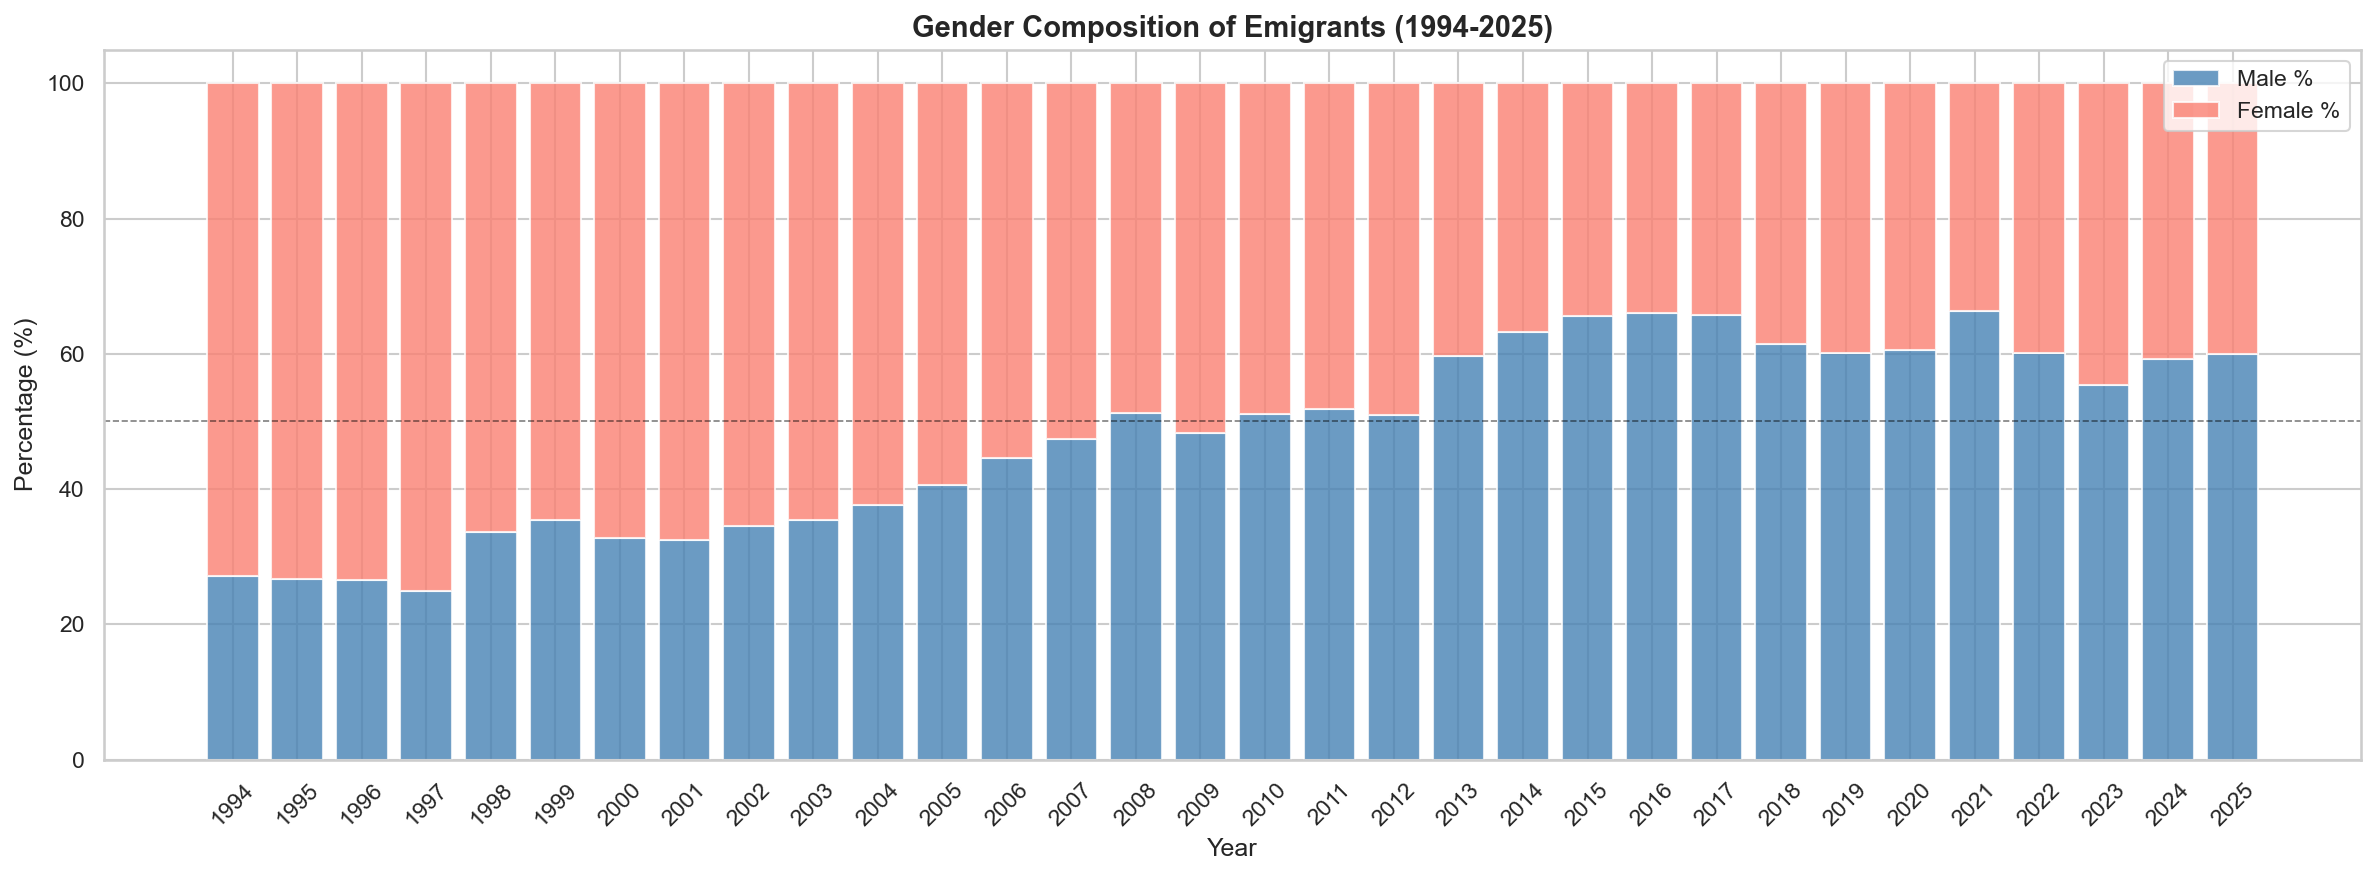

In [18]:
annual['male_pct'] = (annual['male'] / annual['emigration']) * 100
annual['female_pct'] = (annual['female'] / annual['emigration']) * 100

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(annual['year'], annual['male_pct'], label='Male %', color='steelblue', alpha=0.8)
ax.bar(annual['year'], annual['female_pct'], bottom=annual['male_pct'], label='Female %', color='salmon', alpha=0.8)
ax.axhline(50, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Gender Composition of Emigrants (1994-2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Percentage (%)')
ax.legend()
plt.xticks(annual['year'], rotation=45)
plt.tight_layout()
plt.savefig('desc_gender_composition.png')
plt.show()

## 16. Gender Composition by Historical Era

In [19]:
def assign_era(year):
    if year <= 2008:
        return 'Civil War (1994-2008)'
    elif year <= 2019:
        return 'Post-War (2009-2019)'
    else:
        return 'COVID & Crisis (2020-2025)'

annual['era'] = annual['year'].apply(assign_era)

era_gender = annual.groupby('era').agg(
    avg_male_pct=('male_pct', 'mean'),
    avg_female_pct=('female_pct', 'mean'),
    n=('year', 'count')
).round(1)

print('=== Gender Composition by Era ===')
era_gender

=== Gender Composition by Era ===


,avg_male_pct,avg_female_pct,n
era,,,
COVID & Crisis (2020-2025),60.3,39.7,6
Civil War (1994-2008),35.4,64.6,15
Post-War (2009-2019),58.6,41.4,11


## 17. Skill Composition of Emigrants

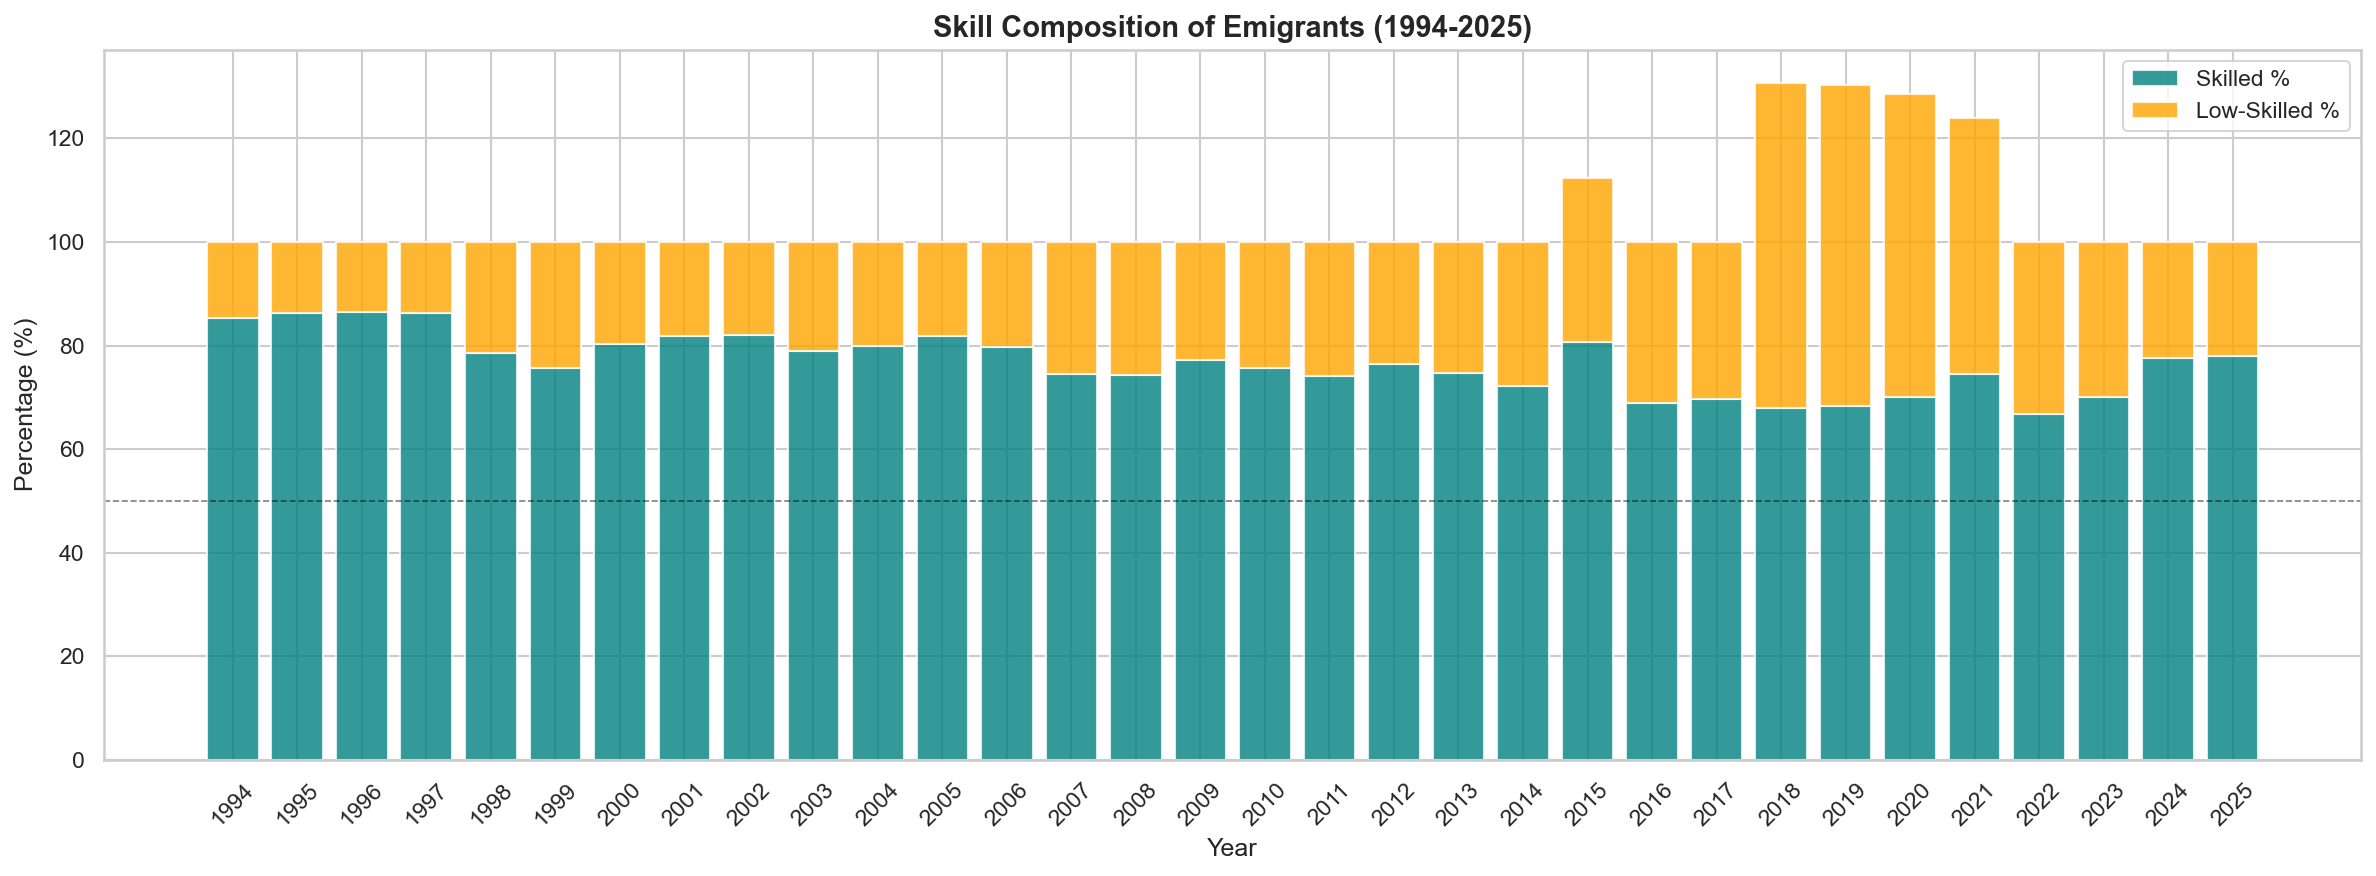

In [20]:
annual['skilled_pct'] = (annual['skilled'] / annual['emigration']) * 100
annual['lowskilled_pct'] = (annual['lowskilled'] / annual['emigration']) * 100

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(annual['year'], annual['skilled_pct'], label='Skilled %', color='teal', alpha=0.8)
ax.bar(annual['year'], annual['lowskilled_pct'], bottom=annual['skilled_pct'], label='Low-Skilled %', color='orange', alpha=0.8)
ax.axhline(50, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Skill Composition of Emigrants (1994-2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Percentage (%)')
ax.legend()
plt.xticks(annual['year'], rotation=45)
plt.tight_layout()
plt.savefig('desc_skill_composition.png')
plt.show()

## 18. Skill Composition by Historical Era

In [21]:
era_skill = annual.groupby('era').agg(
    avg_skilled_pct=('skilled_pct', 'mean'),
    avg_lowskilled_pct=('lowskilled_pct', 'mean'),
    n=('year', 'count')
).round(1)

print('=== Skill Composition by Era ===')
era_skill

=== Skill Composition by Era ===


,avg_skilled_pct,avg_lowskilled_pct,n
era,,,
COVID & Crisis (2020-2025),72.8,35.9,6
Civil War (1994-2008),80.8,19.2,15
Post-War (2009-2019),73.3,33.4,11


## 19. Worker Profile — Age and Contract Duration

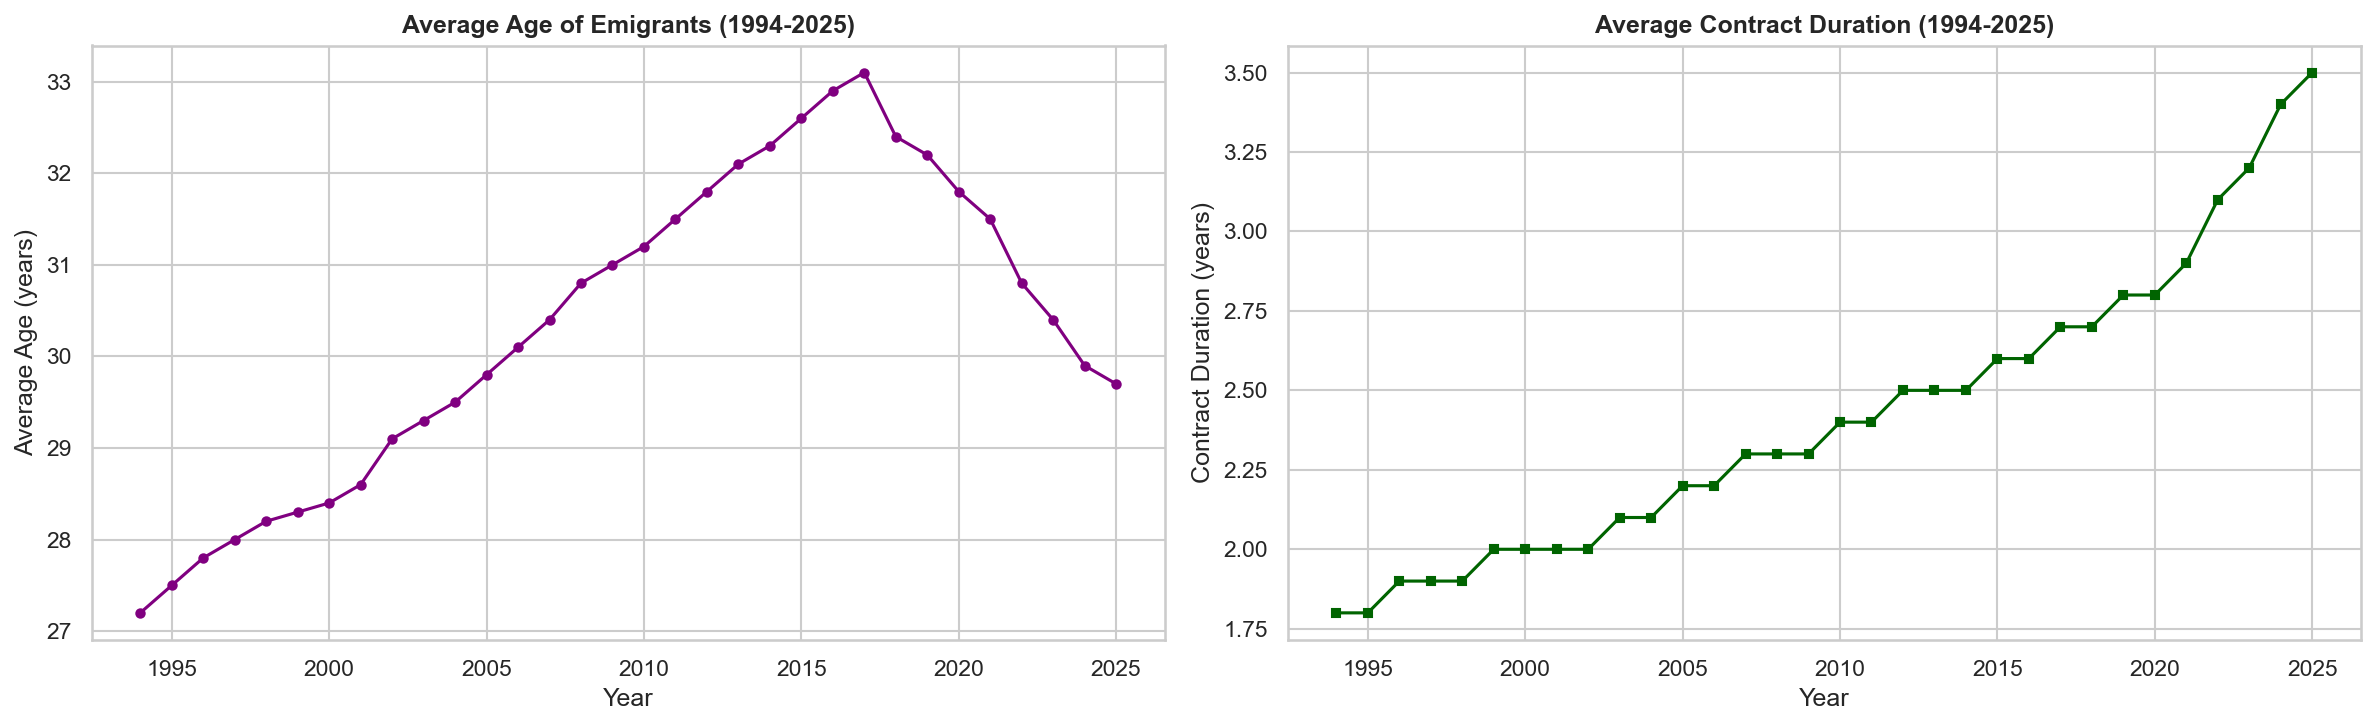

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(annual['year'], annual['avg_age_annual'], marker='o', color='purple', linewidth=1.5, markersize=4)
axes[0].set_title('Average Age of Emigrants (1994-2025)', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Average Age (years)')

axes[1].plot(annual['year'], annual['avg_contract_years_annual'], marker='s', color='darkgreen', linewidth=1.5, markersize=4)
axes[1].set_title('Average Contract Duration (1994-2025)', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Contract Duration (years)')

plt.tight_layout()
plt.savefig('desc_worker_profile.png')
plt.show()

## 20. Year-by-Year Summary Table

In [23]:
summary_table = annual[['year','emigration','male','female','skilled','lowskilled',
                         'remittances','dollar_rate_annual_avg','brent_oil_annual_avg']].copy()
summary_table.columns = ['Year','Emigration','Male','Female','Skilled','LowSkilled',
                          'Remittances (USD Mn)','Dollar Rate (LKR)','Brent Oil (USD)']

print('=== Year-by-Year Summary Table (1994-2025) ===')
summary_table.round(2)

=== Year-by-Year Summary Table (1994-2025) ===


,Year,Emigration,Male,Female,Skilled,LowSkilled,Remittances (USD Mn),Dollar Rate (LKR),Brent Oil (USD)
0,1994,60168,16377,43791,51344,8824,715.19,49.17,15.84
1,1995,172489,46021,126468,148992,23497,800.97,51.06,17.04
2,1996,162576,43112,119464,140647,21929,843.17,55.30,20.64
3,1997,150283,37552,112731,129718,20565,933.73,59.02,19.12
4,1998,159816,53867,105949,125512,34304,1013.34,64.99,12.78
5,1999,179735,63720,116015,135964,43771,1064.30,70.85,17.85
6,2000,182188,59793,122395,146429,35759,1154.29,76.98,28.52
7,2001,184007,59807,124200,150622,33385,1169.81,89.62,24.45
8,2002,203773,70522,133251,167288,36485,1296.07,95.76,24.96
9,2003,209846,74508,135338,165582,44264,1423.47,96.54,28.88


## 21. Distributional Characteristics Summary

In [24]:
dist_summary = pd.DataFrame({
    'Variable': ['Emigration', 'Remittances', 'Dollar Rate', 'Brent Oil'],
    'Skewness': key_annual.skew().values,
    'Kurtosis': key_annual.kurtosis().values,
})

# Add Shapiro-Wilk
sw_results = []
for col in key_annual.columns:
    w, p = stats.shapiro(annual[col] if col in annual.columns else key_annual[col])
    sw_results.append({'W': w, 'p': p, 'Normal': 'Yes' if p > 0.05 else 'No'})
sw_df = pd.DataFrame(sw_results)

dist_summary['SW W'] = sw_df['W'].values
dist_summary['SW p'] = sw_df['p'].values
dist_summary['Normal?'] = sw_df['Normal'].values

print('=== Distributional Characteristics Summary ===')
dist_summary.round(4)

=== Distributional Characteristics Summary ===


,Variable,Skewness,Kurtosis,SW W,SW p,Normal?
0,Emigration,-0.6885,0.4674,0.9480,0.1265,Yes
1,Remittances,0.1250,-1.7313,0.8594,0.0007,No
2,Dollar Rate,1.4010,1.2742,0.8285,0.0001,No
3,Brent Oil,0.2031,-1.1373,0.9356,0.0564,Yes


## 22. Key Descriptive Findings

**[F1] Structural Break — 2022 Economic Crisis:**
The 2022–2023 period represents the most significant structural break in the entire 32-year dataset. The rupee devaluation of +62.20% in 2022 resulted in 4 consecutive IQR outlier years (2022–2025) in the exchange rate series.

**[F2] COVID-19 — 2020 Emigration Outlier:**
The 2020 emigration figure (53,711 workers) is a genuine IQR lower-fence outlier, representing a 73.55% YoY decline — the sharpest in the dataset.

**[F3] Remittances as an Economic Lifeline:**
Remittances grew from USD 715 Mn (1994) to USD 8,076 Mn (2025), an 11.3x increase. Despite the 2020 emigration collapse, remittances rose 5.73% as the existing diaspora sent more money home.

**[F4] Gendered Structural Shift:**
A fundamental shift from female-dominated (Civil War era avg 64.6%) to male-dominated (Post-War era avg 58.6%) emigration, driven by Gulf construction booms and policy restrictions on female domestic workers.

**[F5] Increasing Contract Duration — Desperation Signal:**
Average contract duration increased monotonically from 1.8 years (1994) to 3.5 years (2025), with a near-perfect correlation with the dollar rate (r = 0.951).

**[F6] Oil Price Cycles and Gulf Labour Demand:**
Brent oil prices serve as a proxy for Gulf hiring capacity. The near-normal distribution (W = 0.936, p = 0.056) and absence of IQR outliers make oil the most exogenous variable in the system.